In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] =[10,5]

In [3]:
data = pd.read_excel('NTAD_Fatality_Analysis_Reporting_System_2022_Accidents.xlsx')
df = data.copy()
df.head()

,OBJECTID,STATE,STATENAME,ST_CASE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS,PVH_INVL,PERSONS,...,ARR_HOURNAME,ARR_MIN,ARR_MINNAME,HOSP_HR,HOSP_HRNAME,HOSP_MN,HOSP_MNNAME,FATALS,x,y
0,1,1,Alabama,10001,0,0,2,2,0,3,...,1:00pm-1:59pm,4,4,13,1:00pm-1:59pm,47,47,1,-88.274083,33.490967
1,2,1,Alabama,10002,0,0,2,2,0,5,...,Unknown EMS Scene Arrival Hour,99,Unknown EMS Scene Arrival Minutes,99,Unknown,99,Unknown EMS Hospital Arrival Time,2,-86.064153,32.087125
2,3,1,Alabama,10003,0,0,1,1,0,2,...,1:00am-1:59am,50,50,99,Unknown,99,Unknown EMS Hospital Arrival Time,1,-86.351994,33.428331
3,4,1,Alabama,10004,0,0,1,1,0,1,...,3:00pm-3:59pm,9,9,15,3:00pm-3:59pm,44,44,1,-86.400169,32.216903
4,5,1,Alabama,10005,1,1,1,1,0,1,...,6:00pm-6:59pm,54,54,88,Not Applicable (Not Transported),88,Not Applicable (Not Transported),1,-86.687389,33.540281




#  FARS 2022 Accident Dataset – Column Description

---

##  1. Identification Columns

| Column      | Description                           |
| ----------- | ------------------------------------- |
| `OBJECTID`  | Unique GIS record identifier          |
| `STATE`     | Numeric state code                    |
| `STATENAME` | State name                            |
| `ST_CASE`   | Unique crash case number within state |
| `YEAR`      | Year of crash (2022)                  |

---

##  2. Crash Severity & Involvement

| Column       | Description                                         |
| ------------ | --------------------------------------------------- |
| `PEDS`       | Number of pedestrians involved                      |
| `PERNOTMVIT` | Persons not in motor vehicle (pedestrians/cyclists) |
| `VE_TOTAL`   | Total vehicles involved                             |
| `VE_FORMS`   | Number of vehicles recorded in vehicle file         |
| `PVH_INVL`   | Parked vehicle involved (0 = No)                    |
| `PERSONS`    | Total persons involved                              |
| `PERMVIT`    | Persons in motor vehicles                           |
| `FATALS`     | Number of fatalities in crash                       |

---

##  3. Location Information

| Column         | Description                        |
| -------------- | ---------------------------------- |
| `COUNTY`       | County numeric code                |
| `COUNTYNAME`   | County name                        |
| `CITY`         | City code                          |
| `CITYNAME`     | City name                          |
| `LATITUDE`     | Latitude coordinate                |
| `LATITUDENAME` | Latitude (formatted text version)  |
| `LONGITUD`     | Longitude coordinate               |
| `LONGITUDNAME` | Longitude (formatted text version) |
| `x`            | GIS projected X coordinate         |
| `y`            | GIS projected Y coordinate         |
| `MILEPT`       | Mile point location                |
| `MILEPTNAME`   | Mile point text description        |

---

##  4. Date & Time Information

| Column         | Description                        |
| -------------- | ---------------------------------- |
| `MONTH`        | Month number                       |
| `MONTHNAME`    | Month name                         |
| `DAY`          | Day of month                       |
| `DAYNAME`      | Day name                           |
| `DAY_WEEK`     | Day of week numeric code           |
| `DAY_WEEKNAME` | Day of week name                   |
| `HOUR`         | Hour of crash (0–23)               |
| `HOURNAME`     | Hour range (e.g., 12:00pm–12:59pm) |
| `MINUTE`       | Minute of crash                    |
| `MINUTENAME`   | Minute text version                |

---

##  5. Road & Route Information

| Column      | Description                                                |
| ----------- | ---------------------------------------------------------- |
| `TWAY_ID`   | Primary roadway identifier                                 |
| `TWAY_ID2`  | Secondary roadway identifier                               |
| `ROUTE`     | Route classification code                                  |
| `ROUTENAME` | Route classification name (Interstate, U.S. Highway, etc.) |

---

##  6. Rural / Urban Classification

| Column        | Description                 |
| ------------- | --------------------------- |
| `RUR_URB`     | Rural (1) or Urban (2) code |
| `RUR_URBNAME` | Rural or Urban name         |

---

##  7. Functional System of Road

| Column         | Description                                   |
| -------------- | --------------------------------------------- |
| `FUNC_SYS`     | Functional classification code                |
| `FUNC_SYSNAME` | Road type (Interstate, Major Collector, etc.) |

---

##  8. Road Ownership

| Column         | Description                           |
| -------------- | ------------------------------------- |
| `RD_OWNER`     | Road owner code                       |
| `RD_OWNERNAME` | Road owner name (State, County, City) |

---

##  9. National Highway System (NHS)

| Column    | Description                           |
| --------- | ------------------------------------- |
| `NHS`     | NHS code (1 = On NHS, 0 = Not on NHS) |
| `NHSNAME` | NHS description                       |

---

##  10. Junction & Road Position

| Column         | Description                    |
| -------------- | ------------------------------ |
| `RELJCT1`      | Relation to junction indicator |
| `RELJCT1NAME`  | Junction relation description  |
| `RELJCT2`      | Junction type code             |
| `RELJCT2NAME`  | Junction type description      |
| `TYP_INT`      | Intersection type code         |
| `TYP_INTNAME`  | Intersection type name         |
| `REL_ROAD`     | Position relative to roadway   |
| `REL_ROADNAME` | Road position description      |

---

##  11. Work Zone

| Column         | Description                |
| -------------- | -------------------------- |
| `WRK_ZONE`     | Work zone involvement code |
| `WRK_ZONENAME` | Work zone description      |

---

##  12. Light Conditions

| Column         | Description                                              |
| -------------- | -------------------------------------------------------- |
| `LGT_COND`     | Light condition code                                     |
| `LGT_CONDNAME` | Light condition description (Daylight, Dark, Dawn, etc.) |

---

##  13. Weather Conditions

| Column        | Description                                               |
| ------------- | --------------------------------------------------------- |
| `WEATHER`     | Weather condition code                                    |
| `WEATHERNAME` | Weather condition description (Clear, Rain, Cloudy, etc.) |

---

##  14. School Bus & Rail

| Column        | Description                  |
| ------------- | ---------------------------- |
| `SCH_BUS`     | School bus involvement code  |
| `SCH_BUSNAME` | School bus description       |
| `RAIL`        | Rail involvement code        |
| `RAILNAME`    | Rail involvement description |

---

##  15. EMS & Hospital Timing

| Column         | Description                         |
| -------------- | ----------------------------------- |
| `NOT_HOUR`     | Hour EMS was notified               |
| `NOT_HOURNAME` | EMS notification hour description   |
| `NOT_MIN`      | EMS notification minute             |
| `NOT_MINNAME`  | EMS notification minute description |
| `ARR_HOUR`     | EMS arrival hour                    |
| `ARR_HOURNAME` | EMS arrival hour description        |
| `ARR_MIN`      | EMS arrival minute                  |
| `ARR_MINNAME`  | EMS arrival minute description      |
| `HOSP_HR`      | Hospital arrival hour               |
| `HOSP_HRNAME`  | Hospital arrival hour description   |
| `HOSP_MN`      | Hospital arrival minute             |
| `HOSP_MNNAME`  | Hospital arrival minute description |

---

##  16. Crash Type & Harmful Event

| Column         | Description                     |
| -------------- | ------------------------------- |
| `HARM_EV`      | First harmful event code        |
| `HARM_EVNAME`  | First harmful event description |
| `MAN_COLL`     | Manner of collision code        |
| `MAN_COLLNAME` | Manner of collision description |

---

#  Special Codes

| Code      | Meaning             |
| --------- | ------------------- |
| `0`       | Not applicable      |
| `99`      | Unknown             |
| `0000000` | No rail involvement |

---



# Problem Statement

# Develop a machine learning classification model to predict the severity level (single vs multi-fatal) of a fatal crash based on environmental and roadway conditions.

In [6]:
df.columns

Index(['OBJECTID', 'STATE', 'STATENAME', 'ST_CASE', 'PEDS', 'PERNOTMVIT',
       'VE_TOTAL', 'VE_FORMS', 'PVH_INVL', 'PERSONS', 'PERMVIT', 'COUNTY',
       'COUNTYNAME', 'CITY', 'CITYNAME', 'MONTH', 'MONTHNAME', 'DAY',
       'DAYNAME', 'DAY_WEEK', 'DAY_WEEKNAME', 'YEAR', 'HOUR', 'HOURNAME',
       'MINUTE', 'MINUTENAME', 'TWAY_ID', 'TWAY_ID2', 'ROUTE', 'ROUTENAME',
       'RUR_URB', 'RUR_URBNAME', 'FUNC_SYS', 'FUNC_SYSNAME', 'RD_OWNER',
       'RD_OWNERNAME', 'NHS', 'NHSNAME', 'SP_JUR', 'SP_JURNAME', 'MILEPT',
       'MILEPTNAME', 'LATITUDE', 'LATITUDENAME', 'LONGITUD', 'LONGITUDNAME',
       'HARM_EV', 'HARM_EVNAME', 'MAN_COLL', 'MAN_COLLNAME', 'RELJCT1',
       'RELJCT1NAME', 'RELJCT2', 'RELJCT2NAME', 'TYP_INT', 'TYP_INTNAME',
       'REL_ROAD', 'REL_ROADNAME', 'WRK_ZONE', 'WRK_ZONENAME', 'LGT_COND',
       'LGT_CONDNAME', 'WEATHER', 'WEATHERNAME', 'SCH_BUS', 'SCH_BUSNAME',
       'RAIL', 'RAILNAME', 'NOT_HOUR', 'NOT_HOURNAME', 'NOT_MIN',
       'NOT_MINNAME', 'ARR_HOUR', 'ARR_HOURN

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39681 entries, 0 to 39680
Data columns (total 83 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OBJECTID      39681 non-null  int64  
 1   STATE         39681 non-null  int64  
 2   STATENAME     39681 non-null  object 
 3   ST_CASE       39681 non-null  int64  
 4   PEDS          39681 non-null  int64  
 5   PERNOTMVIT    39681 non-null  int64  
 6   VE_TOTAL      39681 non-null  int64  
 7   VE_FORMS      39681 non-null  int64  
 8   PVH_INVL      39681 non-null  int64  
 9   PERSONS       39681 non-null  int64  
 10  PERMVIT       39681 non-null  int64  
 11  COUNTY        39681 non-null  int64  
 12  COUNTYNAME    39681 non-null  object 
 13  CITY          39681 non-null  int64  
 14  CITYNAME      39681 non-null  object 
 15  MONTH         39681 non-null  int64  
 16  MONTHNAME     39681 non-null  object 
 17  DAY           39681 non-null  int64  
 18  DAYNAME       39681 non-nu

In [8]:
df.shape

(39681, 83)

In [9]:
df.size

3293523

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
OBJECTID,39681.0,19841.000000,11455.062353,1.000000,9921.000000,19841.000000,29761.000000,39681.000000
STATE,39681.0,27.120813,16.509765,1.000000,12.000000,26.000000,42.000000,56.000000
ST_CASE,39681.0,272111.991961,164961.571437,10001.000000,121842.000000,260979.000000,420740.000000,560118.000000
PEDS,39681.0,0.244954,0.616782,0.000000,0.000000,0.000000,0.000000,73.000000
PERNOTMVIT,39681.0,0.254883,0.634328,0.000000,0.000000,0.000000,0.000000,73.000000
VE_TOTAL,39681.0,1.581361,0.845433,1.000000,1.000000,1.000000,2.000000,50.000000
VE_FORMS,39681.0,1.540637,0.803419,1.000000,1.000000,1.000000,2.000000,50.000000
PVH_INVL,39681.0,0.040725,0.289700,0.000000,0.000000,0.000000,0.000000,10.000000
PERSONS,39681.0,2.193291,1.765324,0.000000,1.000000,2.000000,3.000000,128.000000
PERMVIT,39681.0,2.183362,1.761396,0.000000,1.000000,2.000000,3.000000,128.000000


In [11]:
df.duplicated().sum()

0

In [12]:
pd.set_option('display.max_rows', None)

(df.isnull().sum() / len(df)) * 100

OBJECTID         0.000000
STATE            0.000000
STATENAME        0.000000
ST_CASE          0.000000
PEDS             0.000000
PERNOTMVIT       0.000000
VE_TOTAL         0.000000
VE_FORMS         0.000000
PVH_INVL         0.000000
PERSONS          0.000000
PERMVIT          0.000000
COUNTY           0.000000
COUNTYNAME       0.000000
CITY             0.000000
CITYNAME         0.000000
MONTH            0.000000
MONTHNAME        0.000000
DAY              0.000000
DAYNAME          0.000000
DAY_WEEK         0.000000
DAY_WEEKNAME     0.000000
YEAR             0.000000
HOUR             0.000000
HOURNAME         0.000000
MINUTE           0.000000
MINUTENAME       0.000000
TWAY_ID          0.000000
TWAY_ID2        74.796502
ROUTE            0.000000
ROUTENAME        0.000000
RUR_URB          0.000000
RUR_URBNAME      0.000000
FUNC_SYS         0.000000
FUNC_SYSNAME     0.000000
RD_OWNER         0.000000
RD_OWNERNAME     0.000000
NHS              0.000000
NHSNAME          0.000000
SP_JUR      

In [13]:
df.isnull().sum().sum()

74626

In [14]:
df['WRK_ZONENAME'].value_counts()  

WRK_ZONENAME
Construction               487
Work Zone, Type Unknown    290
Maintenance                 47
Utility                      9
Name: count, dtype: int64

In [15]:
df['MILEPTNAME'].nunique()

2337

In [16]:
df['TWAY_ID2'].nunique()

8689

In [17]:
# droping the columns MILEPTNAME and TWAY_ID2 as they don't provide much information for our problem statement and have high cardinality 

df = df.drop(['MILEPTNAME','TWAY_ID2'],axis=1)

In [18]:
# WRK_ZONENAME consists of 97% of null values but we cannot drop it as it is important for our problem statement 
# so perform feature engineering

df["WRK_ZONE_CRASH"] = df["WRK_ZONENAME"].notnull().astype(int)

In [19]:
df['WRK_ZONE_CRASH'].value_counts()

WRK_ZONE_CRASH
0    38848
1      833
Name: count, dtype: int64

In [20]:
df = df.drop('WRK_ZONENAME',axis=1)

In [21]:
df.nunique()

OBJECTID          39681
STATE                52
STATENAME            52
ST_CASE           39681
PEDS                 13
PERNOTMVIT           13
VE_TOTAL             17
VE_FORMS             16
PVH_INVL              9
PERSONS              28
PERMVIT              27
COUNTY              284
COUNTYNAME         2785
CITY               2231
CITYNAME           4412
MONTH                12
MONTHNAME            12
DAY                  31
DAYNAME              31
DAY_WEEK              7
DAY_WEEKNAME          7
YEAR                  1
HOUR                 25
HOURNAME             25
MINUTE               61
MINUTENAME           61
TWAY_ID           19043
ROUTE                 9
ROUTENAME             9
RUR_URB               5
RUR_URBNAME           5
FUNC_SYS             10
FUNC_SYSNAME         10
RD_OWNER             23
RD_OWNERNAME         23
NHS                   3
NHSNAME               3
SP_JUR                8
SP_JURNAME            8
MILEPT             2338
LATITUDE          39258
LATITUDENAME    

In [22]:
# Drop identifier columns
# These columns uniquely identify each crash record and do not contribute to predicting crash severity.
# Keeping them could cause the model to memorize specific records rather than learn meaningful patterns.

df.drop(columns=["OBJECTID","ST_CASE"], inplace=True)

In [23]:
# Drop precise geographic coordinates
# Latitude/longitude and projected coordinates represent exact crash locations.
# Including them may cause the model to memorize specific locations rather than learn general crash patterns.

df.drop(columns=[ "LATITUDE","LATITUDENAME","LONGITUD","LONGITUDNAME","x","y"], inplace=True)

In [24]:
# Drop high-cardinality location identifiers
# County and city variables mainly identify locations and contain many unique values.
# They may introduce overfitting and do not represent environmental or roadway characteristics.

df.drop(columns=[ "COUNTY","COUNTYNAME", "CITY","CITYNAME"], inplace=True)

In [25]:
# Drop specific road identifiers
# TWAY_ID and TWAY_ID2 contain roadway names or identifiers with very high cardinality.
# These act as location references rather than meaningful predictors of crash severity.

df.drop(columns=["TWAY_ID"], inplace=True)

In [26]:
# Drop milepoint reference columns
# Milepoint variables represent the exact position of the crash along a roadway.
# They do not describe roadway conditions and may cause location memorization.

df.drop(columns=[ "MILEPT"], inplace=True)

In [27]:
# Drop coded numeric versions of categorical variables
# The dataset provides both numeric codes and descriptive label versions.
# The label columns are easier to interpret and encode, so numeric code columns are removed.

df.drop(columns=[ "ROUTE", "RUR_URB","FUNC_SYS", "RD_OWNER","NHS","SP_JUR","RELJCT1","RELJCT2","TYP_INT",
                 "REL_ROAD","LGT_COND", "WEATHER","MAN_COLL","HARM_EV"], inplace=True)

In [28]:
# Drop post-crash emergency response variables
# These variables represent EMS notification, arrival, and hospital times.
# They occur after the crash event and would not be available when predicting crash severity.

df.drop(columns=[ "NOT_HOUR", "NOT_HOURNAME", "NOT_MIN","NOT_MINNAME","ARR_HOUR","ARR_HOURNAME","ARR_MIN",
                 "ARR_MINNAME","HOSP_HR","HOSP_HRNAME","HOSP_MN","HOSP_MNNAME"], inplace=True)

In [29]:
# Drop rail variables, minute-level crash timing, and state name.
# Rail events are rare, minute timing is irrelevant, and state names may cause location memorization.

df.drop(columns=["RAIL", "RAILNAME", "MINUTENAME", "STATENAME"],inplace=True)

In [30]:
df.shape

(39681, 37)

# Feature Engineering

In [32]:
# Creating the new target variable based on number of fatals
df["MULTI_FATAL"] = (df["FATALS"] >= 2).astype(int)

In [33]:
df['FATALS'].value_counts()

FATALS
1    36985
2     2253
3      319
4       92
5       24
6        5
9        2
8        1
Name: count, dtype: int64

In [34]:
df.drop('FATALS',axis=1,inplace=True)

In [35]:
df['MULTI_FATAL'].value_counts()

MULTI_FATAL
0    36985
1     2696
Name: count, dtype: int64

In [36]:
# Create new Weekend crash indicator
df["WEEKEND_CRASH"] = df["DAY_WEEKNAME"].isin(["Saturday","Sunday"]).astype(int)

In [37]:
df["WEEKEND_CRASH"].value_counts()

WEEKEND_CRASH
0    26453
1    13228
Name: count, dtype: int64

In [38]:
# Multi-vehicle crash indicator
df["MULTI_VEHICLE_CRASH"] = (df["VE_TOTAL"] > 1).astype(int)

In [39]:
df["VE_TOTAL"].value_counts()

VE_TOTAL
1     21643
2     14675
3      2429
4       581
5       197
6        89
7        27
8        16
9         7
11        7
10        3
12        2
20        1
17        1
16        1
50        1
13        1
Name: count, dtype: int64

In [40]:
df["MULTI_VEHICLE_CRASH"].value_counts()

MULTI_VEHICLE_CRASH
0    21643
1    18038
Name: count, dtype: int64

In [41]:
# Ratio of people to vehicles
# It gives the avg no of persons in a vehicle

df["PERSONS_PER_VEHICLE"] = df["PERSONS"] / (df["VE_TOTAL"])

In [42]:
df["PERSONS_PER_VEHICLE"].value_counts()

PERSONS_PER_VEHICLE
1.000000     25024
2.000000      5209
1.500000      3839
3.000000      1335
2.500000       733
1.333333       650
0.500000       516
4.000000       494
1.666667       339
5.000000       214
3.500000       171
0.666667       138
1.250000       129
0.333333        93
2.333333        92
6.000000        77
1.750000        67
2.666667        49
1.200000        43
0.000000        38
4.500000        35
7.000000        31
1.400000        27
8.000000        25
0.750000        24
1.600000        24
0.250000        23
2.250000        22
2.200000        12
3.333333        12
1.166667        11
0.400000        11
1.142857        10
5.500000        10
3.666667         9
0.200000         9
0.800000         9
12.000000        7
1.800000         7
2.750000         6
11.000000        5
9.000000         5
1.285714         4
0.166667         4
1.833333         4
10.000000        4
0.833333         4
2.800000         3
13.000000        3
4.333333         3
0.600000         3
2.400000   

In [43]:
# Create a binary feature indicating low-visibility crash conditions.
# Low visibility includes dark lighting, dawn, and dusk conditions,
# which may increase crash severity due to reduced driver visibility.

df["NIGHT_CRASH"] = df["LGT_CONDNAME"].isin([ "Dark – Not Lighted","Dark – Lighted", "Dark – Unknown Lighting","Dusk","Dawn"]).astype(int)

In [44]:
df["LGT_CONDNAME"].value_counts()

LGT_CONDNAME
Daylight                   17816
Dark - Not Lighted         10782
Dark - Lighted              8685
Dusk                         926
Dawn                         732
Dark - Unknown Lighting      434
Reported as Unknown          230
Not Reported                  58
Other                         18
Name: count, dtype: int64

In [45]:
df['NIGHT_CRASH'].value_counts()

NIGHT_CRASH
0    38023
1     1658
Name: count, dtype: int64

In [46]:
df["RURAL_NIGHT_CRASH"] = ((df["RUR_URBNAME"] == "Rural") & (df["NIGHT_CRASH"] == 1)).astype(int)

In [47]:
df["RUR_URBNAME"].value_counts()

RUR_URBNAME
Urban                                23863
Rural                                15696
Trafficway Not in State Inventory       89
Unknown                                 27
Not Reported                             6
Name: count, dtype: int64

In [48]:
df["RURAL_NIGHT_CRASH"].value_counts()

RURAL_NIGHT_CRASH
0    38994
1      687
Name: count, dtype: int64

In [49]:
df.columns

Index(['STATE', 'PEDS', 'PERNOTMVIT', 'VE_TOTAL', 'VE_FORMS', 'PVH_INVL',
       'PERSONS', 'PERMVIT', 'MONTH', 'MONTHNAME', 'DAY', 'DAYNAME',
       'DAY_WEEK', 'DAY_WEEKNAME', 'YEAR', 'HOUR', 'HOURNAME', 'MINUTE',
       'ROUTENAME', 'RUR_URBNAME', 'FUNC_SYSNAME', 'RD_OWNERNAME', 'NHSNAME',
       'SP_JURNAME', 'HARM_EVNAME', 'MAN_COLLNAME', 'RELJCT1NAME',
       'RELJCT2NAME', 'TYP_INTNAME', 'REL_ROADNAME', 'WRK_ZONE',
       'LGT_CONDNAME', 'WEATHERNAME', 'SCH_BUS', 'SCH_BUSNAME',
       'WRK_ZONE_CRASH', 'MULTI_FATAL', 'WEEKEND_CRASH', 'MULTI_VEHICLE_CRASH',
       'PERSONS_PER_VEHICLE', 'NIGHT_CRASH', 'RURAL_NIGHT_CRASH'],
      dtype='object')

In [50]:
num = df.select_dtypes(include=['int64','float64']).columns.to_list()
cat = df.select_dtypes(include='object').columns.to_list()

In [51]:
IQR=df[num].quantile(0.75) - df[num].quantile(0.25)

In [52]:
upper_whis= df[num].quantile(0.75) + (1.5*IQR)
lower_whis= df[num].quantile(0.25) - (1.5*IQR)

In [53]:
outlier = df[((df[num]<lower_whis)|(df[num]>upper_whis)).any(axis=1)]
outlier.head()

,STATE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS,PVH_INVL,PERSONS,PERMVIT,MONTH,MONTHNAME,...,WEATHERNAME,SCH_BUS,SCH_BUSNAME,WRK_ZONE_CRASH,MULTI_FATAL,WEEKEND_CRASH,MULTI_VEHICLE_CRASH,PERSONS_PER_VEHICLE,NIGHT_CRASH,RURAL_NIGHT_CRASH
1,1,0,0,2,2,0,5,5,1,January,...,Clear,0,No,0,1,1,1,2.5,0,0
4,1,1,1,1,1,0,1,1,1,January,...,Rain,0,No,0,0,1,0,1.0,0,0
5,1,1,1,1,1,0,5,5,1,January,...,Clear,0,No,0,0,1,0,5.0,0,0
11,1,0,0,2,2,0,2,2,1,January,...,Cloudy,0,No,0,1,0,1,1.0,0,0
13,1,0,0,2,2,0,3,3,1,January,...,Clear,0,No,0,0,0,1,1.5,1,1


In [54]:
len(outlier)/len(df)*100

42.47372798064565

In [55]:
# Standardize missing categorical values.
# In FARS dataset, categories like "Unknown", "Reported as Unknown",
# and "Not Reported" represent missing information rather than true categories.

unknown_values = ["Unknown","Reported as Unknown","Not Reported"]

df.replace(unknown_values, np.nan, inplace=True)

In [56]:
df[cat]=df[cat].fillna('No information')

In [57]:
for col in cat:
    print(col)
    print()
    print(df[col].value_counts())
    print()

MONTHNAME

MONTHNAME
October      3732
September    3632
August       3602
July         3579
May          3404
June         3396
December     3274
November     3242
March        3080
April        2991
January      2978
February     2771
Name: count, dtype: int64

DAY_WEEKNAME

DAY_WEEKNAME
Saturday     7092
Sunday       6136
Friday       6054
Thursday     5295
Wednesday    5124
Monday       5033
Tuesday      4947
Name: count, dtype: int64

HOURNAME

HOURNAME
9:00pm-9:59pm      2355
6:00pm-6:59pm      2352
8:00pm-8:59pm      2327
7:00pm-7:59pm      2238
10:00pm-10:59pm    2127
5:00pm-5:59pm      2063
4:00pm-4:59pm      1981
3:00pm-3:59pm      1843
11:00pm-11:59pm    1783
2:00pm-2:59pm      1743
0:00am-0:59am      1711
2:00am-2:59am      1606
1:00am-1:59am      1524
12:00pm-12:59pm    1485
6:00am-6:59am      1478
1:00pm-1:59pm      1454
5:00am-5:59am      1295
7:00am-7:59am      1265
11:00am-11:59am    1252
10:00am-10:59am    1177
9:00am-9:59am      1132
3:00am-3:59am      1102
8:00am-8:

# EDA

# Target Analysis

In [60]:
df["MULTI_FATAL"].value_counts()

MULTI_FATAL
0    36985
1     2696
Name: count, dtype: int64

In [61]:
df["MULTI_FATAL"].value_counts(normalize=True)*100

MULTI_FATAL
0    93.205816
1     6.794184
Name: proportion, dtype: float64

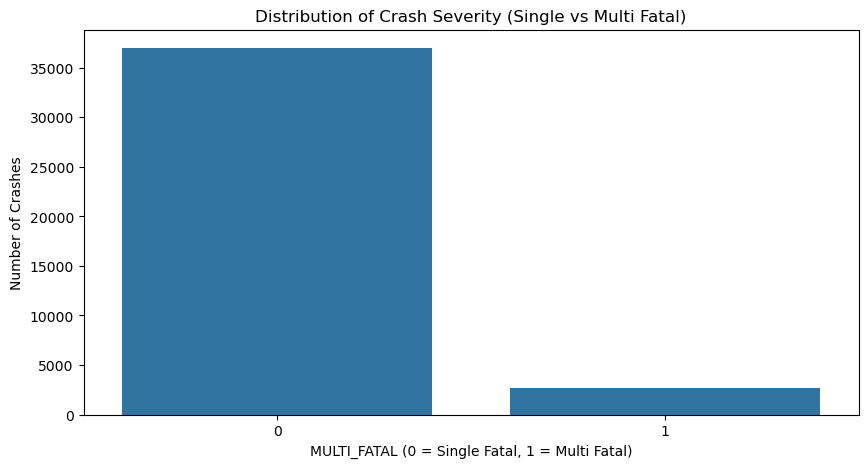

In [62]:
# Check distribution of the target variable
# This helps us understand if the dataset is imbalanced.
# Multi-fatal crashes are usually rare compared to single-fatal crashes.

sns.countplot(x="MULTI_FATAL", data=df)

plt.title("Distribution of Crash Severity (Single vs Multi Fatal)")
plt.xlabel("MULTI_FATAL (0 = Single Fatal, 1 = Multi Fatal)")
plt.ylabel("Number of Crashes")

plt.show()

# Univariate Analysis for numerical features

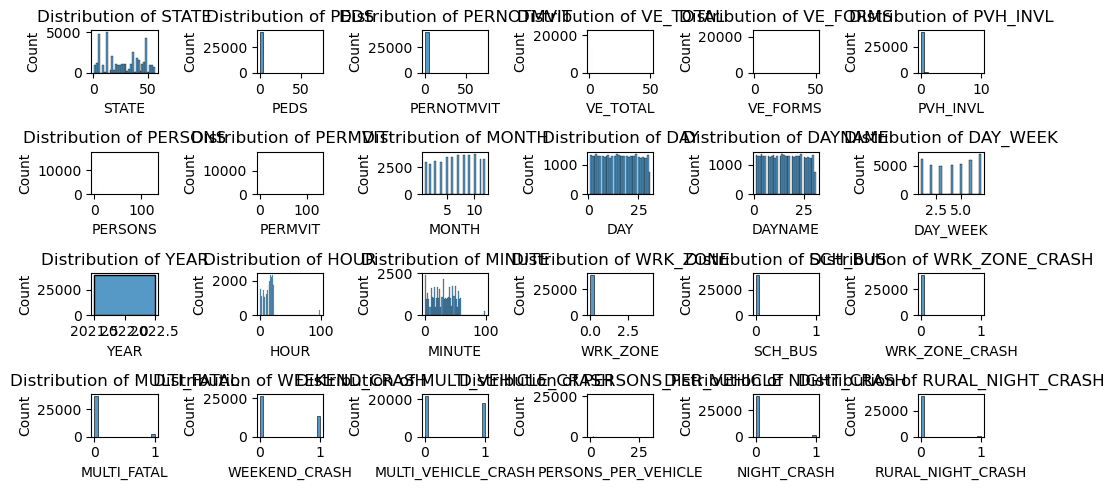

In [64]:
t=1
for i in num:
    plt.subplot(4,6,t)
    sns.histplot(df[i])
    plt.title(f'Distribution of {i}')
    t+=1
plt.tight_layout()
plt.show()

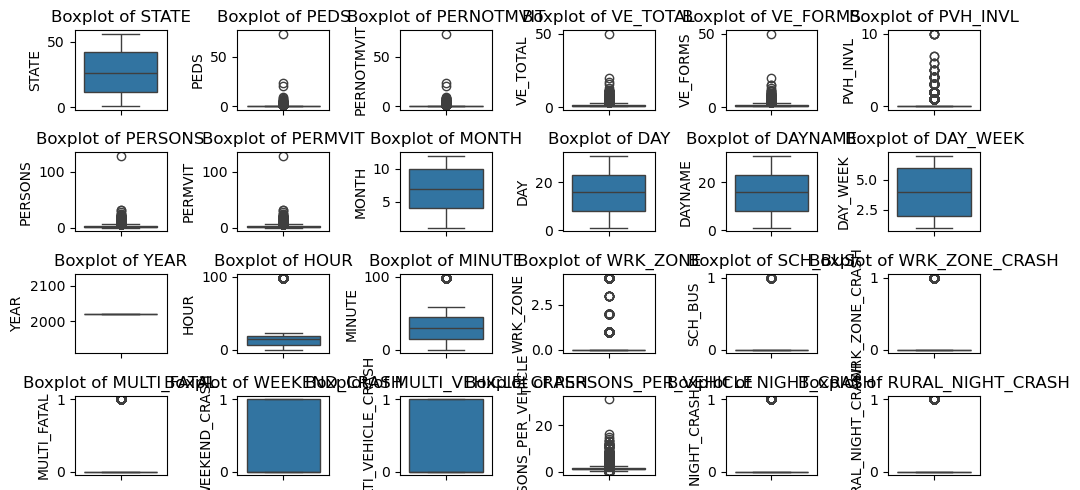

In [65]:
t=1
for i in num:
    plt.subplot(4,6,t)
    sns.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    t+=1
plt.tight_layout()
plt.show()

In [66]:
len(cat)

18

# Bivariate Analysis

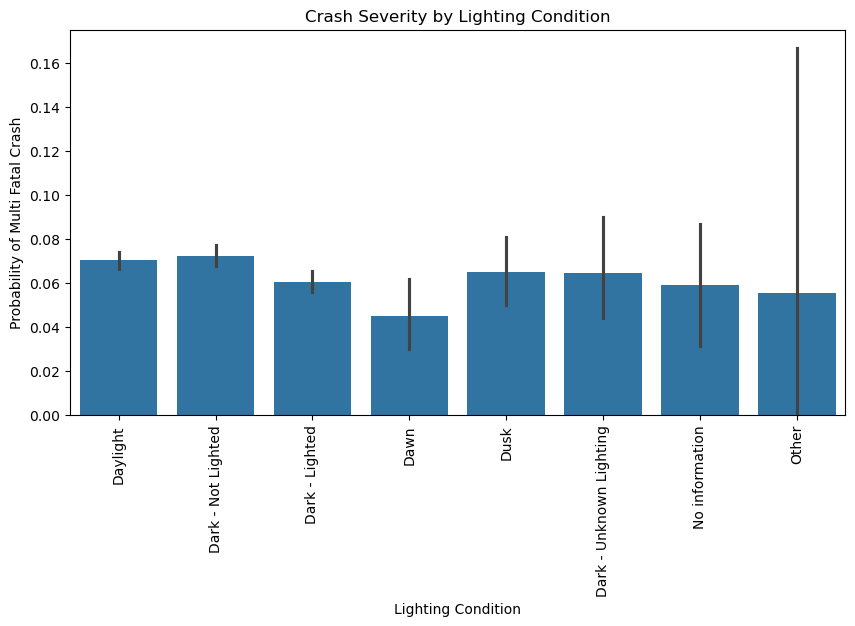

In [68]:
# Analyze how lighting conditions affect fatal crash severity
# Poor lighting is expected to increase crash severity.

sns.barplot(
    x="LGT_CONDNAME",
    y="MULTI_FATAL",
    data=df
)

plt.title("Crash Severity by Lighting Condition")
plt.xlabel("Lighting Condition")
plt.ylabel("Probability of Multi Fatal Crash")

plt.xticks(rotation=90)

plt.show()

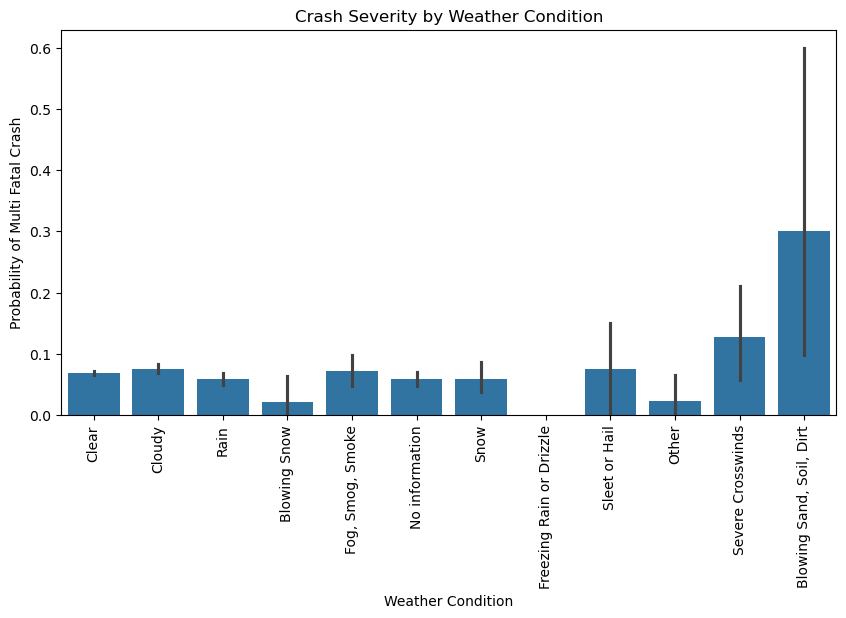

In [69]:
# Analyze how weather conditions affect crash severity
# Bad weather reduces visibility and road friction.

sns.barplot(
    x="WEATHERNAME",
    y="MULTI_FATAL",
    data=df
)

plt.title("Crash Severity by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Probability of Multi Fatal Crash")

plt.xticks(rotation=90)

plt.show()

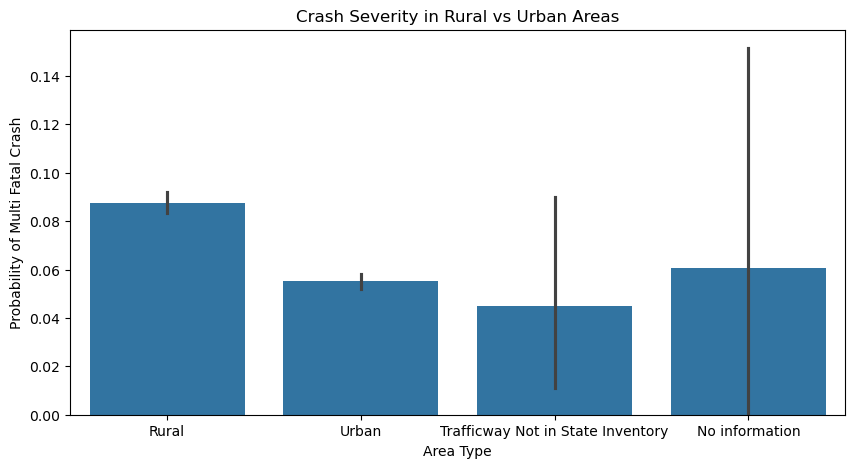

In [70]:
# Compare crash severity between rural and urban areas
# Rural crashes often have higher fatality rates due to:
# higher speeds, longer emergency response time, fewer hospitals

sns.barplot(
    x="RUR_URBNAME",
    y="MULTI_FATAL",
    data=df
)

plt.title("Crash Severity in Rural vs Urban Areas")
plt.xlabel("Area Type")
plt.ylabel("Probability of Multi Fatal Crash")

plt.show()

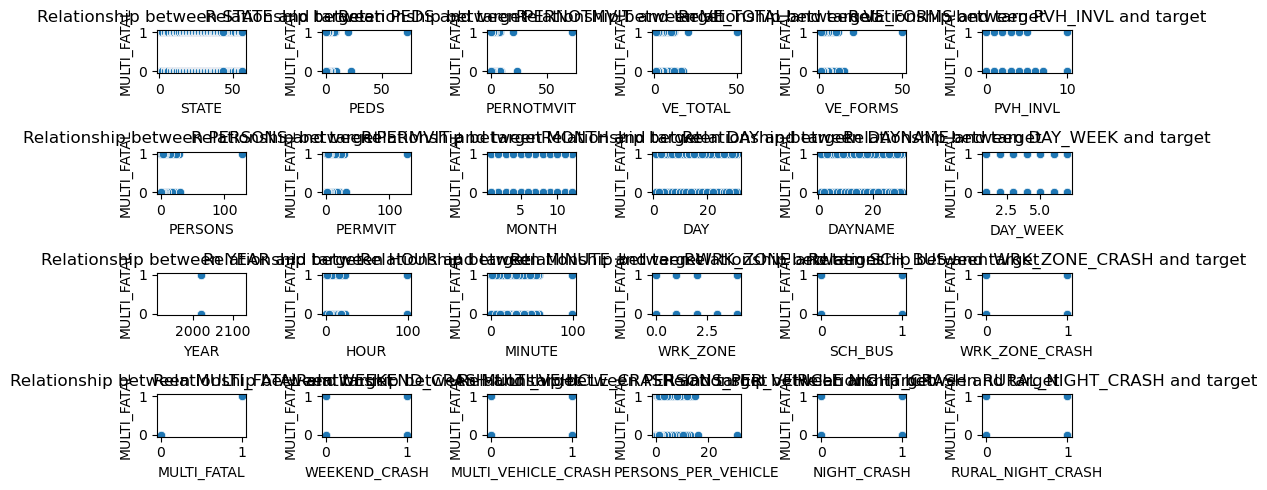

In [71]:
t = 1
for i in num:
        plt.subplot(4,6,t)
        sns.scatterplot(x=df[i], y=df['MULTI_FATAL'])
        plt.title(f'Relationship between {i} and target')
        t+=1
plt.tight_layout()
plt.show()

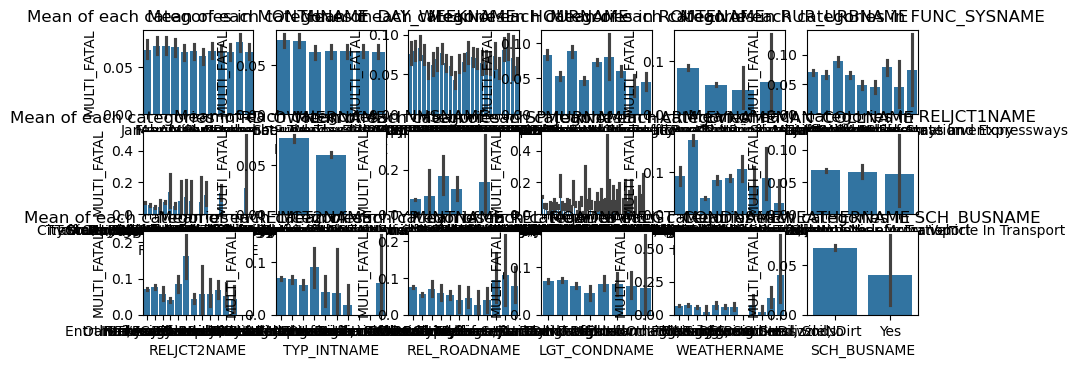

In [72]:
t=1
for i in cat:
    plt.subplot(4,6,t)
    sns.barplot(x=df[i], y = df['MULTI_FATAL'])
    plt.title(f'Mean of each categories in {i}')
    t+=1
plt.tight_layout()
plt.show()

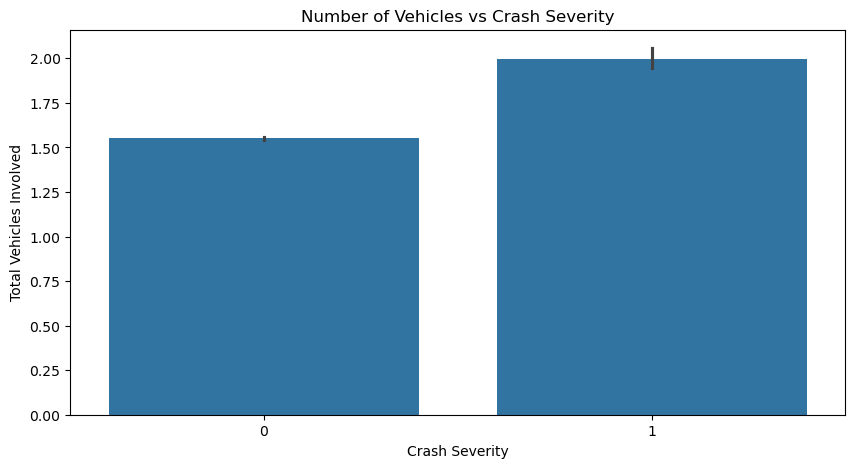

In [73]:
# Analyze how the number of vehicles involved affects crash severity
# Multi-vehicle crashes can increase collision complexity.

sns.barplot(
    x="MULTI_FATAL",
    y="VE_TOTAL",
    data=df
)

plt.title("Number of Vehicles vs Crash Severity")
plt.xlabel("Crash Severity")
plt.ylabel("Total Vehicles Involved")

plt.show()

# Engineered Feature vs Target analysis

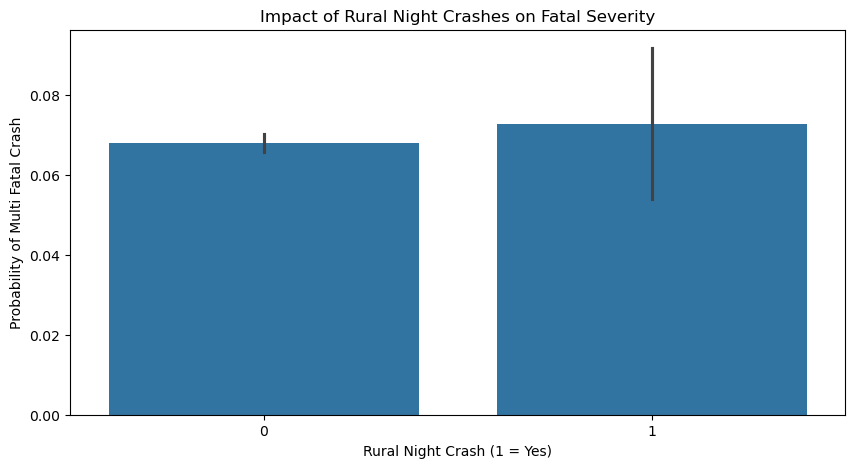

In [75]:
# Validate the importance of the engineered feature:
# RURAL_NIGHT_CRASH
# This feature captures high-risk conditions where crashes
# occur at night or in low visibility timings in rural areas.

sns.barplot(
    x="RURAL_NIGHT_CRASH",
    y="MULTI_FATAL",
    data=df
)

plt.title("Impact of Rural Night Crashes on Fatal Severity")
plt.xlabel("Rural Night Crash (1 = Yes)")
plt.ylabel("Probability of Multi Fatal Crash")

plt.show()

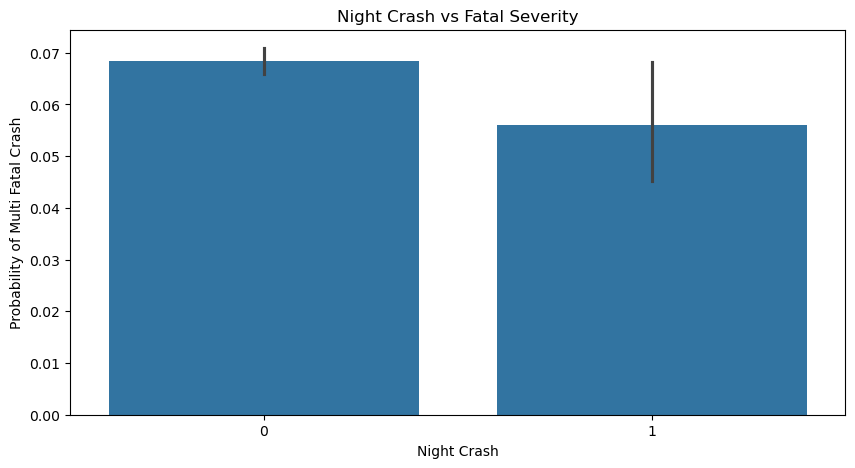

In [76]:
# Check if night crashes are more severe than daytime crashes

sns.barplot(
    x="NIGHT_CRASH",
    y="MULTI_FATAL",
    data=df
)

plt.title("Night Crash vs Fatal Severity")
plt.xlabel("Night Crash")
plt.ylabel("Probability of Multi Fatal Crash")

plt.show()

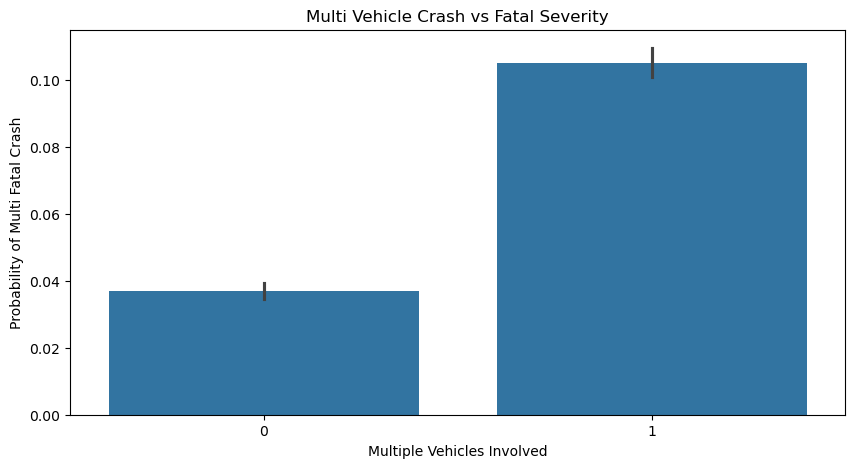

In [77]:
# -----------------------------------------------------------
# Check if crashes involving multiple vehicles
# increase fatal severity.
# -----------------------------------------------------------

sns.barplot(
    x="MULTI_VEHICLE_CRASH",
    y="MULTI_FATAL",
    data=df
)

plt.title("Multi Vehicle Crash vs Fatal Severity")
plt.xlabel("Multiple Vehicles Involved")
plt.ylabel("Probability of Multi Fatal Crash")

plt.show()

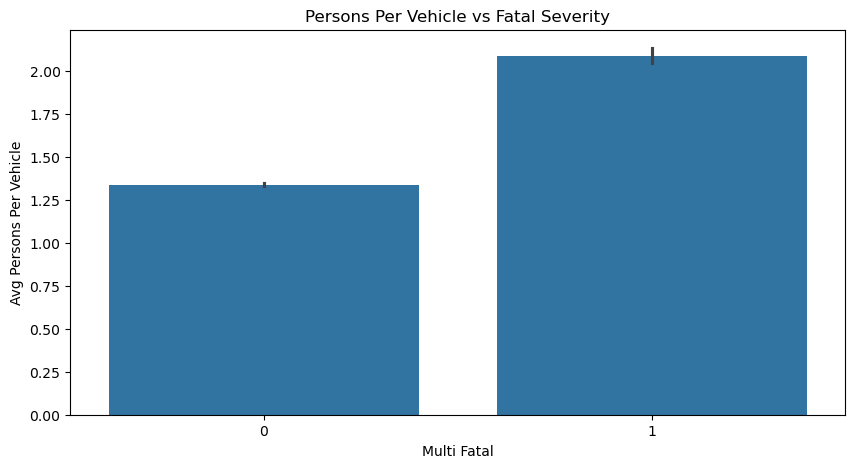

In [78]:
# Higher passenger density may increase fatal outcomes

sns.barplot(
    x="MULTI_FATAL",
    y="PERSONS_PER_VEHICLE",
    data=df
)

plt.title("Persons Per Vehicle vs Fatal Severity")
plt.xlabel("Multi Fatal")
plt.ylabel("Avg Persons Per Vehicle")

plt.show()

# Multivariate analysis

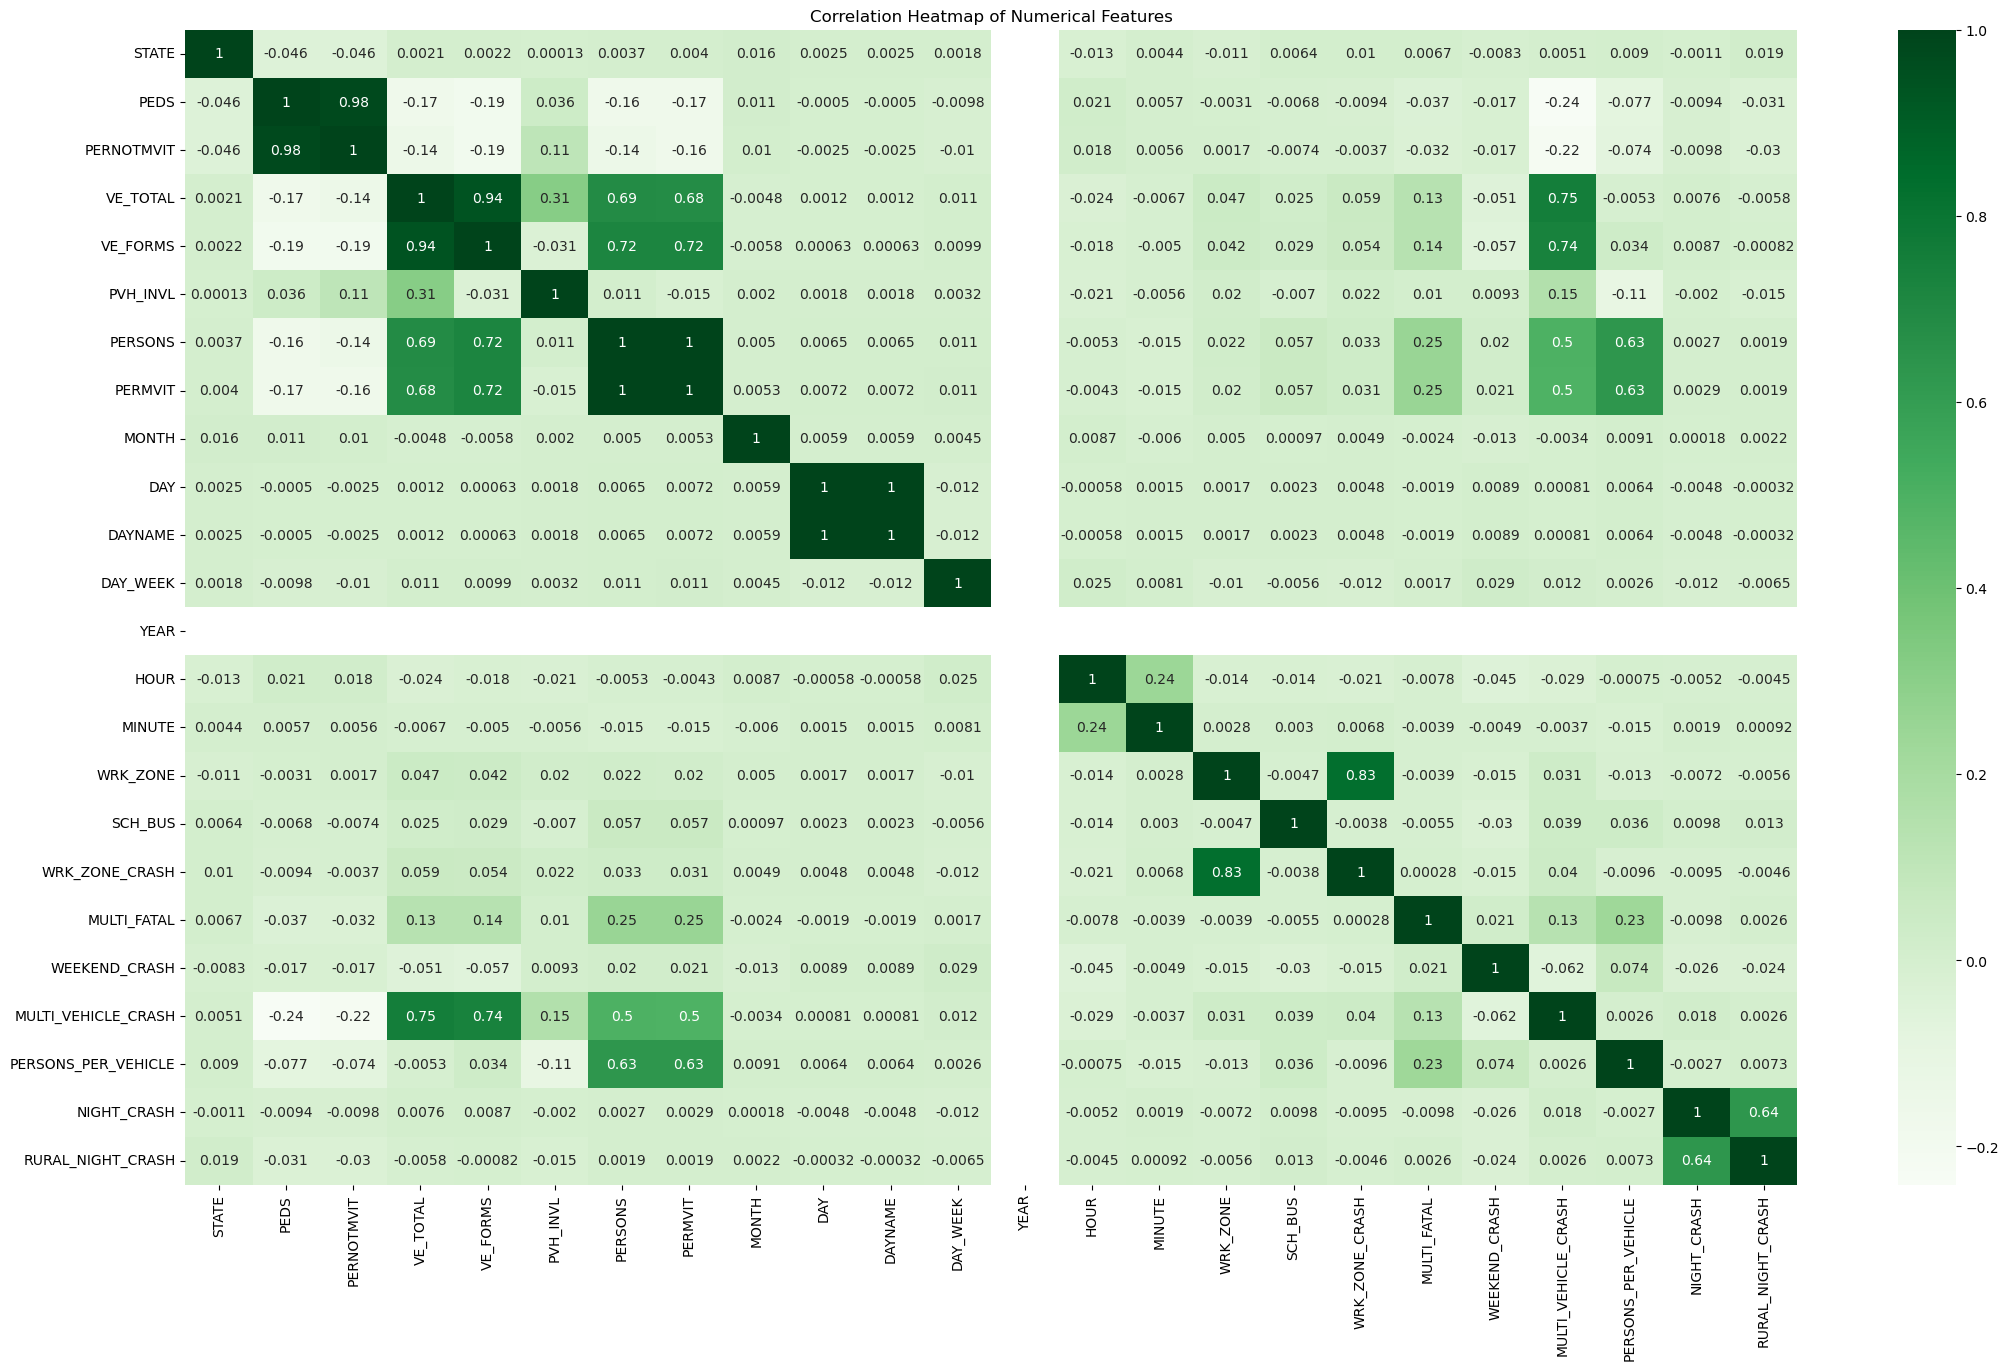

In [80]:
plt.figure(figsize=(26,15))

corr = df[num].corr()
sns.heatmap(corr,annot=True, cmap = 'Greens')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

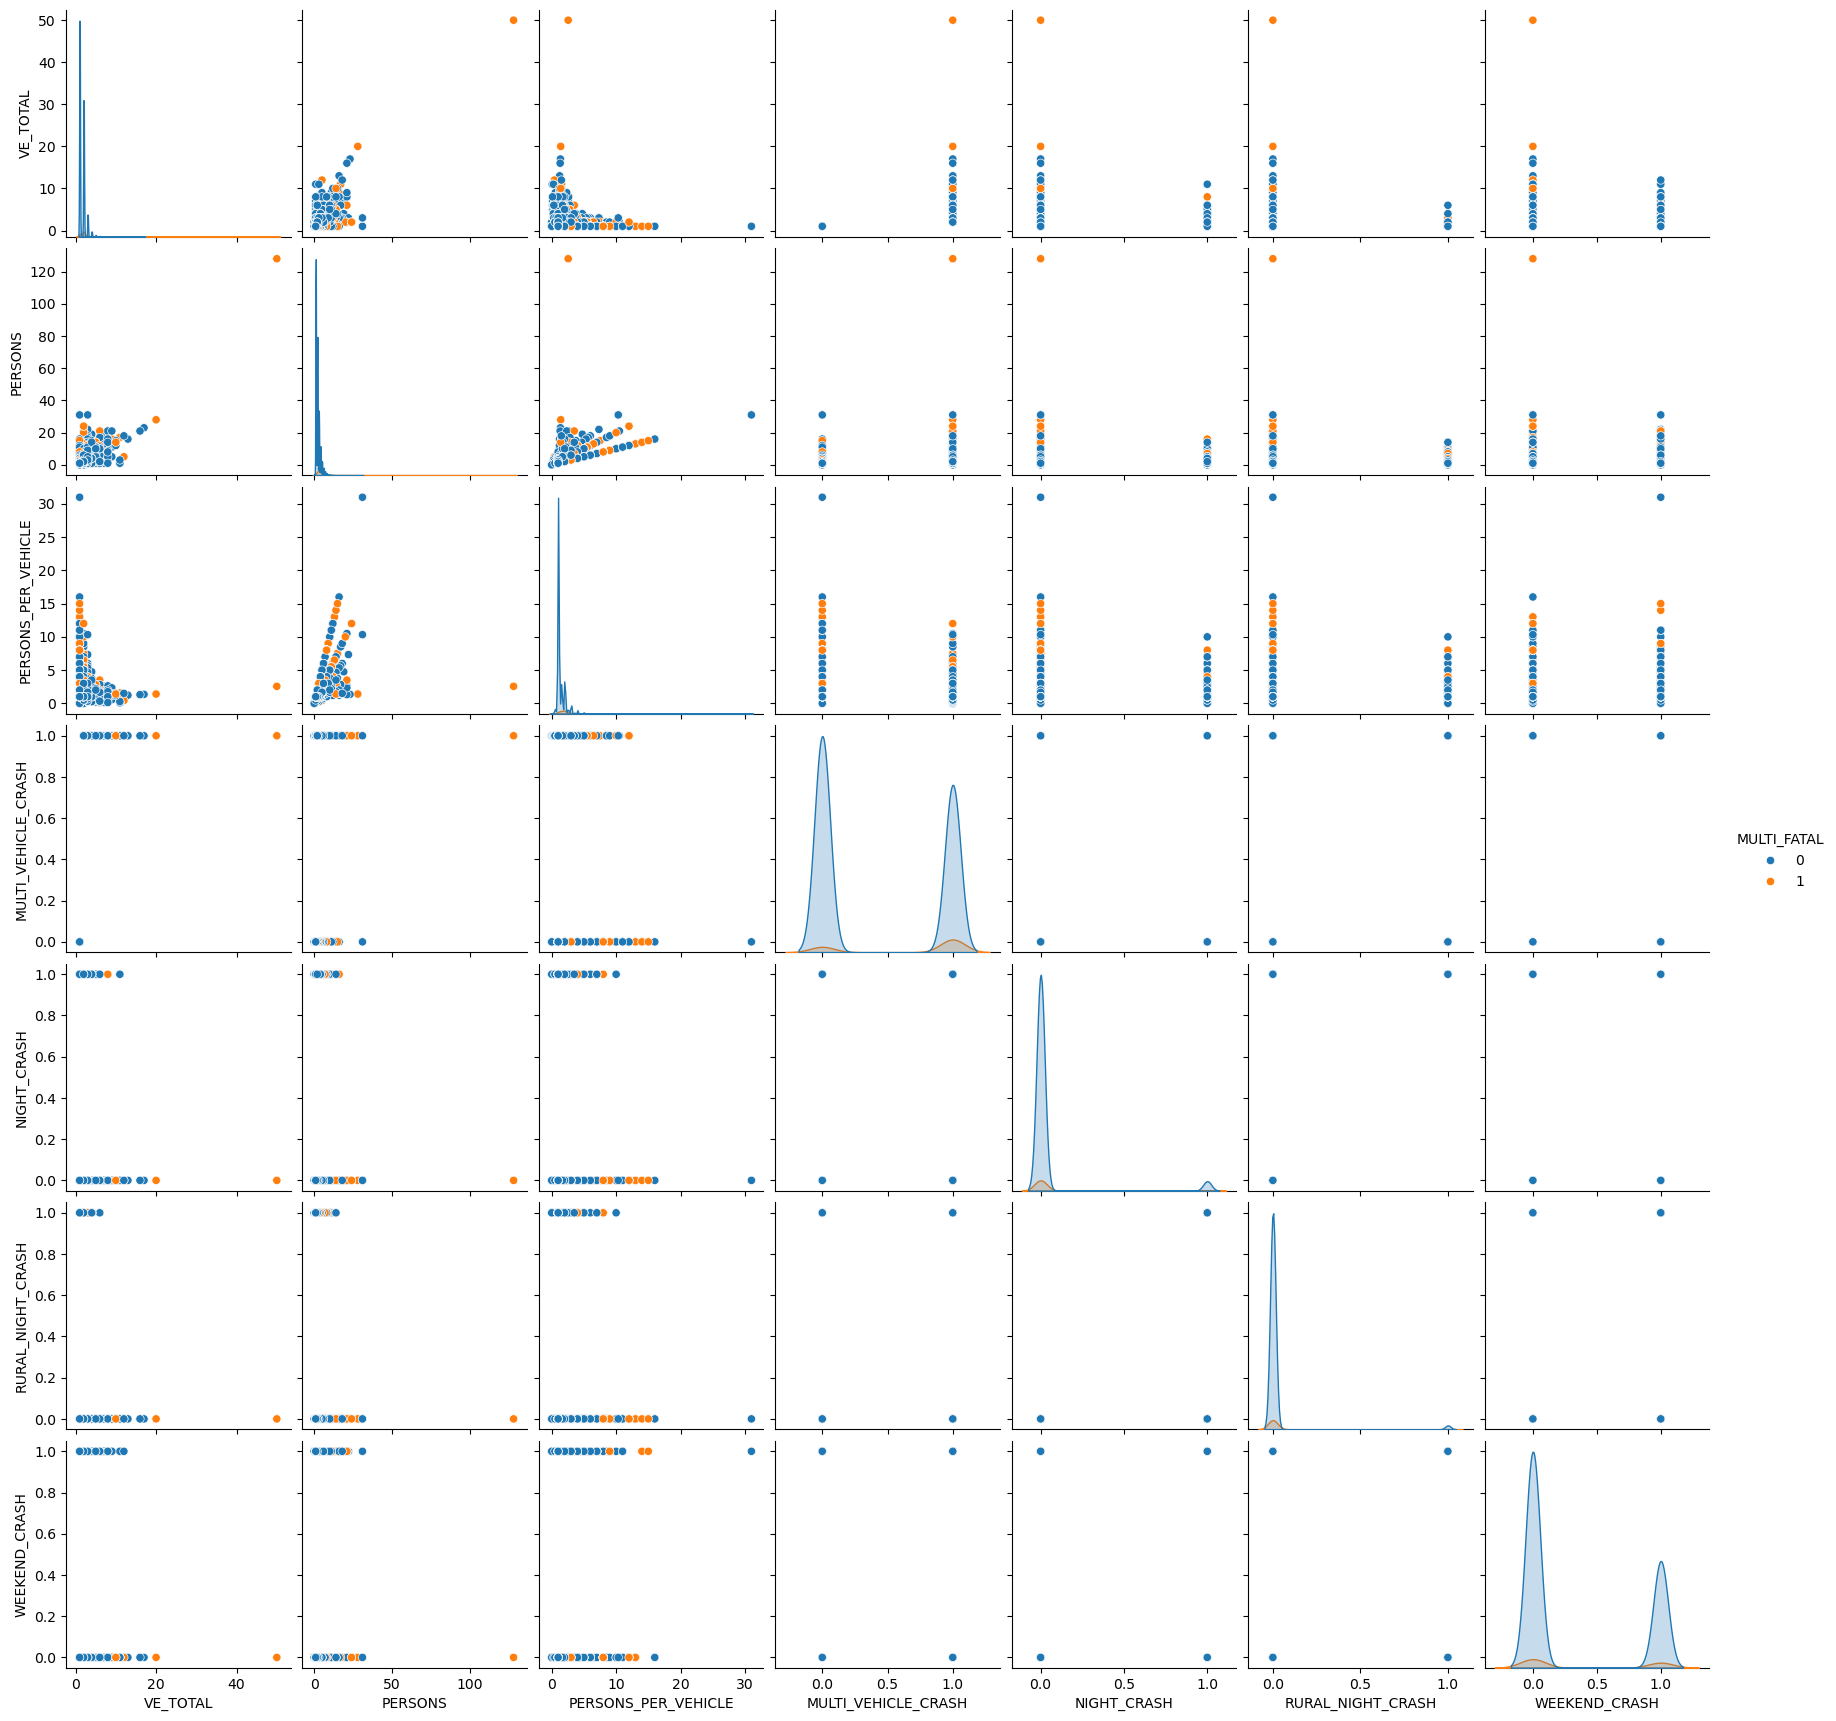

In [81]:
# Pairplot to visualize relationships between important features and crash severity

pairplot_features = [
    "MULTI_FATAL",
    "VE_TOTAL",
    "PERSONS",
    "PERSONS_PER_VEHICLE",
    "MULTI_VEHICLE_CRASH",
    "NIGHT_CRASH",
    "RURAL_NIGHT_CRASH",
    "WEEKEND_CRASH"
]

sns.pairplot(df[pairplot_features], hue="MULTI_FATAL")

plt.show()

In [82]:
df[cat].nunique().sort_values(ascending=False)

HARM_EVNAME     55
HOURNAME        25
RD_OWNERNAME    22
RELJCT2NAME     14
WEATHERNAME     12
REL_ROADNAME    12
MONTHNAME       12
TYP_INTNAME     10
MAN_COLLNAME     9
FUNC_SYSNAME     9
ROUTENAME        9
SP_JURNAME       8
LGT_CONDNAME     8
DAY_WEEKNAME     7
RUR_URBNAME      4
NHSNAME          3
RELJCT1NAME      3
SCH_BUSNAME      2
dtype: int64

In [83]:
len(cat)

18

In [84]:
# One-hot encode all categorical columns which is safe for all models
df = pd.get_dummies(df, columns=cat, drop_first=True)

df.shape

(39681, 230)

# Model Building

In [86]:
x = df.drop(columns=["MULTI_FATAL"],axis=1)
y = df["MULTI_FATAL"]



In [87]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(x_train.shape, x_test.shape)

(31744, 229) (7937, 229)


In [88]:
y.value_counts(normalize=True)

MULTI_FATAL
0    0.932058
1    0.067942
Name: proportion, dtype: float64

In [89]:
from sklearn.preprocessing import StandardScaler

# Scaling for Logistic Regression
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Logistic Regression

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score,roc_curve,cohen_kappa_score,accuracy_score,precision_score,f1_score,recall_score
                                  


lr_model = LogisticRegression()
lr_model.fit(x_train_scaled,y_train)


LogisticRegression()

In [92]:
ypred_s_lr = lr_model.predict_proba(x_test_scaled)[:,1]
ypred_h_lr = (ypred_s_lr > 0.5).astype(int)


In [93]:
summary = pd.DataFrame(columns=['Name','Accuracy','Precision','Recall','F1_Score','ROC_AUC','Cohen_Kappa'])

def metrics(model, name, x_train, y_train, x_test, y_test):
    global summary
    
    # fit the model
    model.fit(x_train, y_train)
    
    # Soft predictions (probabilities)
    ypred_soft = model.predict_proba(x_test)[:,1]
    
    # Hard predictions (labels)
    ypred_hard = (ypred_soft > 0.5).astype(int)

    # Confusion matrix
    print("Confusion Matrix:\n",confusion_matrix(y_test, ypred_hard))
    
    # Print classification report
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test, ypred_hard))
    print('----------------------------------------------------------------')
    
    # Metrics
    acc   = round(accuracy_score(y_test, ypred_hard), 2)
    pre   = round(precision_score(y_test, ypred_hard), 2)
    rec   = round(recall_score(y_test, ypred_hard), 2)
    f1    = round(f1_score(y_test, ypred_hard), 2)
    auc   = round(roc_auc_score(y_test, ypred_soft), 2)
    reliability = round(cohen_kappa_score(y_test, ypred_hard), 2)
    
    # Append to summary DataFrame
    result = pd.DataFrame({
        'Name':[name],
        'Accuracy':[acc],
        'Precision':[pre],
        'Recall':[rec],
        'F1_Score':[f1],
        'ROC_AUC':[auc],
        'Cohen_Kappa':[reliability]
    })
    
    summary = pd.concat([summary, result], ignore_index=True)

    return summary

In [94]:
metrics(lr_model,'Logistic Regression',x_train_scaled,y_train,x_test_scaled,y_test)

Confusion Matrix:
 [[7356   42]
 [ 511   28]]

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      7398
           1       0.40      0.05      0.09       539

    accuracy                           0.93      7937
   macro avg       0.67      0.52      0.53      7937
weighted avg       0.90      0.93      0.90      7937

----------------------------------------------------------------


,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.4,0.05,0.09,0.82,0.08


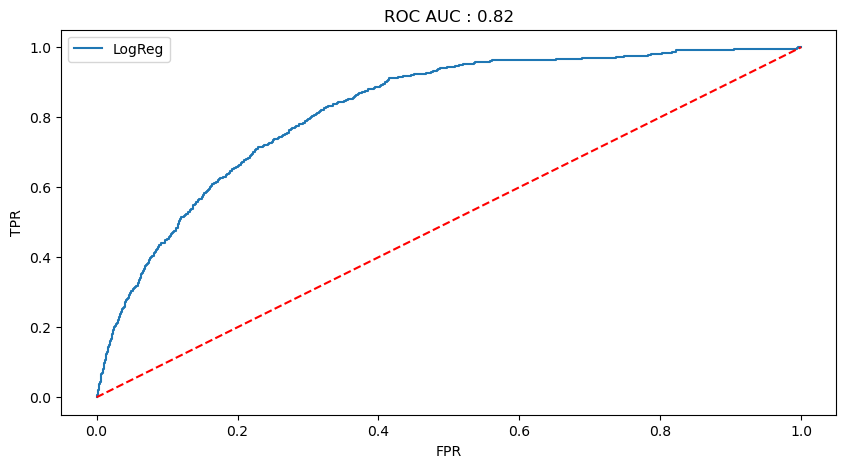

In [95]:
# plot the roc curve 
fpr_lr,tpr_lr,thres_lr = roc_curve(y_test,ypred_s_lr)

plt.plot(fpr_lr,tpr_lr,label = 'LogReg')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_lr),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# Inferences

1. The model achieves **93% accuracy**, but this is misleading due to the **strong class imbalance** where single-fatal crashes dominate the dataset.

2.  The model predicts **single-fatal crashes (Class 0)** very well, with an **F1-score of 0.96**, indicating strong performance for the majority class.

3.  The model performs **very poorly for multi-fatal crashes (Class 1)** with an **F1-score of 0.09**.

4.  The recall for multi-fatal crashes is **only 5%**, meaning the model fails to detect most multi-fatal crash cases.

5.  The **ROC-AUC score of 0.82** suggests the model can reasonably distinguish between the classes, but threshold bias and class imbalance prevent effective prediction of the minority class.



# Logistic Regression using Balanced data (SMOTE)

In [98]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42,sampling_strategy=0.8)

# Apply only on training data
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

In [99]:
print(x_train_smote.shape)
print(y_train_smote.value_counts())

(53256, 229)
MULTI_FATAL
0    29587
1    23669
Name: count, dtype: int64


In [100]:
log_model_smote = LogisticRegression()

log_model_smote.fit(x_train_smote, y_train_smote)

LogisticRegression()

In [101]:
ypred_s_lr_smote = log_model_smote.predict_proba(x_test_scaled)[:,1]
ypred_h_lr_smote = (ypred_s_lr_smote > 0.5).astype(int)


In [102]:
metrics(log_model_smote,'Logistic Regression tuned',x_train_smote,y_train_smote,x_test_scaled,y_test)

Confusion Matrix:
 [[5952 1446]
 [ 188  351]]

Classification Report for Logistic Regression tuned:

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      7398
           1       0.20      0.65      0.30       539

    accuracy                           0.79      7937
   macro avg       0.58      0.73      0.59      7937
weighted avg       0.92      0.79      0.84      7937

----------------------------------------------------------------


,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.4,0.05,0.09,0.82,0.08
1,Logistic Regression tuned,0.79,0.2,0.65,0.30,0.83,0.22


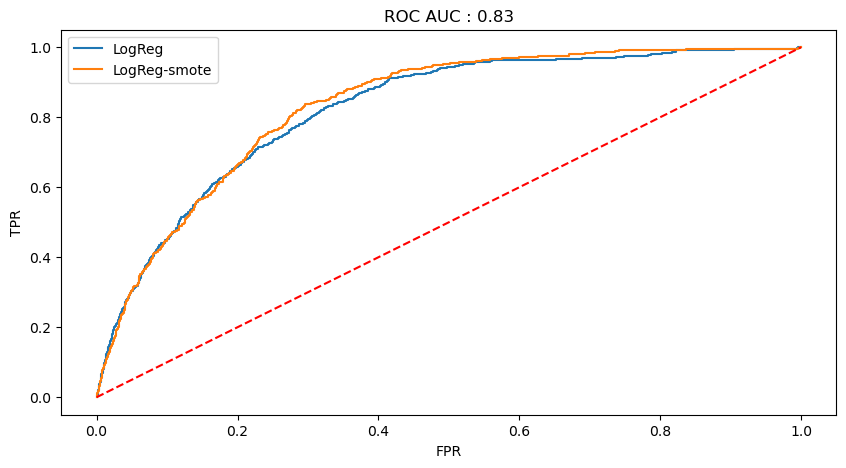

In [103]:
# plot the roc curve 
fpr_lr_smote,tpr_lr_smote,thres_lr_smote = roc_curve(y_test,ypred_s_lr_smote)

plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_smote,tpr_lr_smote,label='LogReg-smote')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_lr_smote),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# Inferences

1. Recall improved significantly for Class 1: The model now detects 65% of multi-fatal crashes, a major improvement from before (~5%).

2. Better minority class detection but with trade-off: False positives increased (1446 cases), meaning more single-fatal crashes are     misclassified.

 
3. Overall accuracy dropped to 79%, which is expected and acceptable after handling class imbalance.

 
4. F1-score for Class 1 improved to 0.30, showing better balance between precision and recall, though still needs improvement.

   
5. ROC-AUC (~0.83) remains strong, indicating the model still has good ability to distinguish between classes.

# Model Comparison: Before vs After SMOTE

| Metric               | Before SMOTE | After SMOTE | Change                      |
| -------------------- | ------------ | ----------- | --------------------------- |
| Accuracy             | **93%**      | **79%**     | ⬇ Decreased (expected)      |
| Recall (Class 1)     | **0.05**     | **0.65**    | ⬆ Huge improvement        |
| Precision (Class 1)  | ~0.15        | **0.20**    | ⬆ Slight improvement        |
| F1-score (Class 1)   | **0.09**     | **0.30**    | ⬆ Significant improvement  |
| False Negatives (FN) | **511**      | **188**     | ⬇ Reduced (very good)      |
| False Positives (FP) | **42**       | **1446**    | ⬆ Increased (trade-off)   |
| ROC-AUC              | **0.82**     | **0.83**    | ⬆ Slight improvement        |


# Decision Tree

In [107]:
from sklearn.tree import DecisionTreeClassifier


In [108]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [109]:
ypred_s_dt = dt_model.predict_proba(x_test)[:,1]
ypred_h_dt = (ypred_s_dt > 0.5).astype(int)


In [110]:
metrics(dt_model,'Decision Tree',x_train,y_train,x_test,y_test)

Confusion Matrix:
 [[6917  481]
 [ 414  125]]

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7398
           1       0.21      0.23      0.22       539

    accuracy                           0.89      7937
   macro avg       0.57      0.58      0.58      7937
weighted avg       0.89      0.89      0.89      7937

----------------------------------------------------------------


,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.40,0.05,0.09,0.82,0.08
1,Logistic Regression tuned,0.79,0.20,0.65,0.30,0.83,0.22
2,Decision Tree,0.89,0.21,0.23,0.22,0.58,0.16


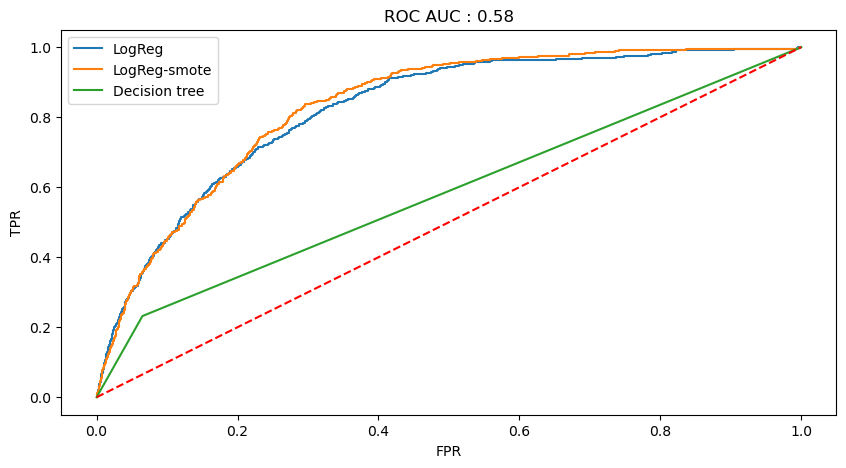

In [111]:
# plot the roc curve 
fpr_dt,tpr_dt,thres_dt = roc_curve(y_test,ypred_s_dt)

plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_smote,tpr_lr_smote,label='LogReg-smote')
plt.plot(fpr_dt,tpr_dt,label='Decision tree')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_dt),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# Inferences

1. Accuracy improved to 89%, but still influenced by class imbalance.
2. Poor detection of multi-fatal crashes: Recall for Class 1 is only 23%, meaning most critical cases are still missed.
3. F1-score for Class 1 is low (0.22), indicating weak performance on the minority class.
4. ROC-AUC dropped to 0.58, showing the model has poor class separation ability compared to Logistic Regression (~0.82).
5. Model is biased toward majority class, despite some improvement over the baseline.

# Random Forest

In [114]:
from sklearn.ensemble import RandomForestClassifier

In [115]:
# Initialize model (default parameters)
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [116]:
ypred_s_rf = rf_model.predict_proba(x_test)[:,1]
ypred_h_rf = (ypred_s_rf > 0.5).astype(int)


In [117]:
metrics(rf_model,'Random Forest',x_train,y_train,x_test,y_test)

Confusion Matrix:
 [[7390    8]
 [ 533    6]]

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      7398
           1       0.43      0.01      0.02       539

    accuracy                           0.93      7937
   macro avg       0.68      0.51      0.49      7937
weighted avg       0.90      0.93      0.90      7937

----------------------------------------------------------------


,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.40,0.05,0.09,0.82,0.08
1,Logistic Regression tuned,0.79,0.20,0.65,0.30,0.83,0.22
2,Decision Tree,0.89,0.21,0.23,0.22,0.58,0.16
3,Random Forest,0.93,0.43,0.01,0.02,0.86,0.02


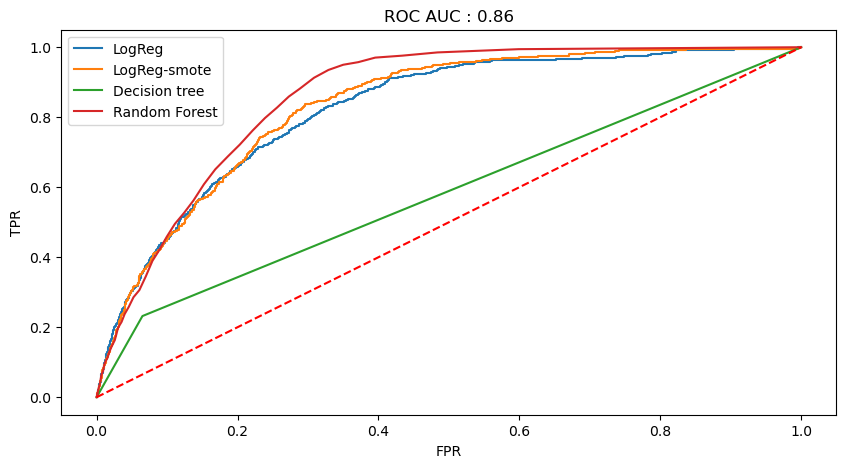

In [118]:
# plot the roc curve 
fpr_rf,tpr_rf,thres_rf = roc_curve(y_test,ypred_s_rf)

plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_smote,tpr_lr_smote,label='LogReg-smote')
plt.plot(fpr_dt,tpr_dt,label='Decision tree')
plt.plot(fpr_rf,tpr_rf,label='Random Forest')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_rf),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# Inferences

1. High accuracy (93%) but misleading, as the model predicts almost all cases as single-fatal.
2. Extremely poor recall for Class 1 (1%), meaning the model is missing almost all multi-fatal crashes.
3. Very high bias toward majority class, with only 6 true positives detected out of 539.
4. ROC-AUC is high (0.85), showing the model has good separation ability but is not using the correct threshold.
5. Model behaves like a majority classifier, prioritizing accuracy over detecting critical minority cases.

# Random Forest with Tuning

In [121]:
from sklearn.model_selection import GridSearchCV

In [122]:
param_grid = {
    "n_estimators": [70,100,200],
    "max_depth": [8, 12, 16],
    "min_samples_split": [20, 50],
    "min_samples_leaf": [10, 20],
    "class_weight": ["balanced"]
}

In [123]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="f1",   # important for imbalance
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'], 'max_depth': [8, 12, 16],
                         'min_samples_leaf': [10, 20],
                         'min_samples_split': [20, 50],
                         'n_estimators': [70, 100, 200]},
             scoring='f1', verbose=2)

In [124]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 16, 'min_samples_leaf': 10, 'min_samples_split': 50, 'n_estimators': 70}


In [125]:
rf_tuned = RandomForestClassifier(random_state=42,class_weight= 'balanced', max_depth= 16, min_samples_leaf= 10, min_samples_split= 50, 
                                  n_estimators= 70)

In [126]:
rf_tuned.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=16,
                       min_samples_leaf=10, min_samples_split=50,
                       n_estimators=70, random_state=42)

In [127]:
ypred_s_rftuned = rf_tuned.predict_proba(x_test)[:,1]
ypred_h_rftuned = (ypred_s_rftuned > 0.5).astype(int)


In [128]:
metrics(rf_tuned,'Random Forest Tuned',x_train,y_train,x_test,y_test)

Confusion Matrix:
 [[5300 2098]
 [  59  480]]

Classification Report for Random Forest Tuned:

              precision    recall  f1-score   support

           0       0.99      0.72      0.83      7398
           1       0.19      0.89      0.31       539

    accuracy                           0.73      7937
   macro avg       0.59      0.80      0.57      7937
weighted avg       0.93      0.73      0.80      7937

----------------------------------------------------------------


,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.40,0.05,0.09,0.82,0.08
1,Logistic Regression tuned,0.79,0.20,0.65,0.30,0.83,0.22
2,Decision Tree,0.89,0.21,0.23,0.22,0.58,0.16
3,Random Forest,0.93,0.43,0.01,0.02,0.86,0.02
4,Random Forest Tuned,0.73,0.19,0.89,0.31,0.86,0.22


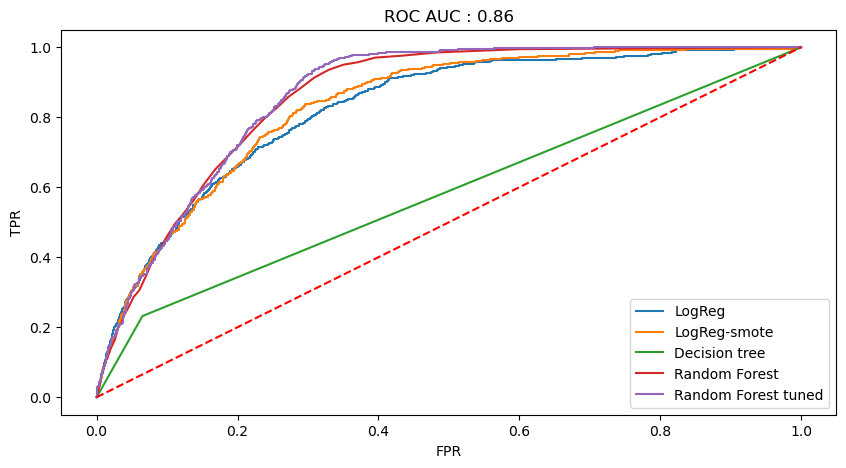

In [129]:
# plot the roc curve 
fpr_rftuned,tpr_rftuned,thres_rftuned = roc_curve(y_test,ypred_s_rftuned)

plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_smote,tpr_lr_smote,label='LogReg-smote')
plt.plot(fpr_dt,tpr_dt,label='Decision tree')
plt.plot(fpr_rf,tpr_rf,label='Random Forest')
plt.plot(fpr_rftuned,tpr_rftuned,label='Random Forest tuned')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_rftuned),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# Inferences

1. Excellent recall for Class 1 (89%) — the model now detects almost all multi-fatal crashes.
2. Very high false positives (2098)  — many single-fatal crashes are misclassified as multi-fatal.
3. F1-score for Class 1 improved to 0.31 — better balance between precision and recall compared to previous models.
4. Accuracy dropped to 73%, which is expected due to aggressive detection of minority class.
5. High ROC-AUC (0.86)  — model has strong ability to distinguish between classes.

# XG Boost

In [132]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [133]:
from xgboost import XGBClassifier

In [134]:
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

# Remove special characters
x_train.columns = x_train.columns.str.replace('[', '', regex=False)\
                                   .str.replace(']', '', regex=False)\
                                   .str.replace('<', '', regex=False)

x_test.columns = x_test.columns.str.replace('[', '', regex=False)\
                                 .str.replace(']', '', regex=False)\
                                 .str.replace('<', '', regex=False)

In [135]:
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [136]:
ypred_s_xgb = xgb_model.predict_proba(x_test)[:,1]
ypred_h_xgb = (ypred_s_xgb > 0.5).astype(int)


In [137]:
metrics(xgb_model,'XGBoost',x_train,y_train,x_test,y_test)

Confusion Matrix:
 [[7337   61]
 [ 500   39]]

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      7398
           1       0.39      0.07      0.12       539

    accuracy                           0.93      7937
   macro avg       0.66      0.53      0.54      7937
weighted avg       0.90      0.93      0.91      7937

----------------------------------------------------------------


,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.40,0.05,0.09,0.82,0.08
1,Logistic Regression tuned,0.79,0.20,0.65,0.30,0.83,0.22
2,Decision Tree,0.89,0.21,0.23,0.22,0.58,0.16
3,Random Forest,0.93,0.43,0.01,0.02,0.86,0.02
4,Random Forest Tuned,0.73,0.19,0.89,0.31,0.86,0.22
5,XGBoost,0.93,0.39,0.07,0.12,0.86,0.10


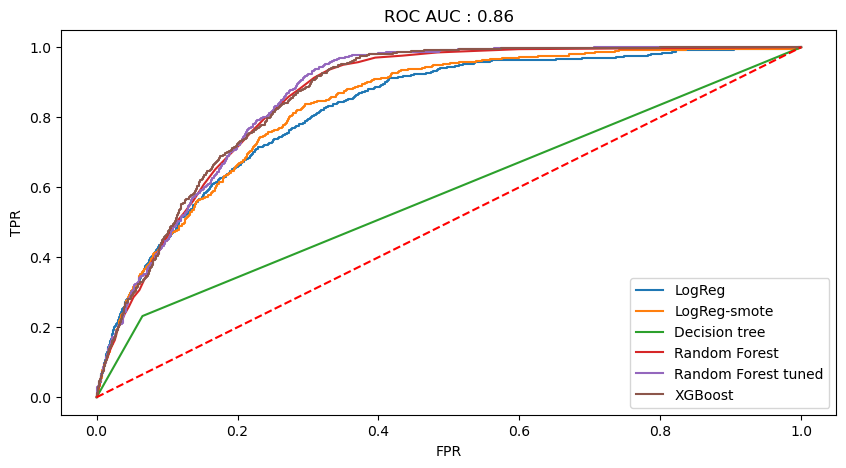

In [138]:
# plot the roc curve 
fpr_xgb,tpr_xgb,thres_xgb = roc_curve(y_test,ypred_s_xgb)

plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_smote,tpr_lr_smote,label='LogReg-smote')
plt.plot(fpr_dt,tpr_dt,label='Decision tree')
plt.plot(fpr_rf,tpr_rf,label='Random Forest')
plt.plot(fpr_rftuned,tpr_rftuned,label='Random Forest tuned')
plt.plot(fpr_xgb,tpr_xgb,label = 'XGBoost')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_xgb),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# XG Boost Tuned

In [140]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

In [141]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1],
    "scale_pos_weight": [ratio]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",   # important for imbalance
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

In [143]:
best_xgb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'scale_pos_weight': 13.716736207695874, 'subsample': 0.8}


In [144]:
xgb_tuned = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    colsample_bytree= 0.8, learning_rate= 0.05, max_depth= 8, n_estimators= 200, scale_pos_weight= 13.716736207695874, subsample= 0.8
)

xgb_tuned.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [145]:
ypred_s_xgb_tuned = xgb_tuned.predict_proba(x_test)[:,1]
ypred_h_xgb_tuned = (ypred_s_xgb_tuned > 0.5).astype(int)


In [146]:
metrics(xgb_tuned,'XGBoost tuned',x_train,y_train,x_test,y_test)

Confusion Matrix:
 [[5749 1649]
 [ 133  406]]

Classification Report for XGBoost tuned:

              precision    recall  f1-score   support

           0       0.98      0.78      0.87      7398
           1       0.20      0.75      0.31       539

    accuracy                           0.78      7937
   macro avg       0.59      0.77      0.59      7937
weighted avg       0.92      0.78      0.83      7937

----------------------------------------------------------------


,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.40,0.05,0.09,0.82,0.08
1,Logistic Regression tuned,0.79,0.20,0.65,0.30,0.83,0.22
2,Decision Tree,0.89,0.21,0.23,0.22,0.58,0.16
3,Random Forest,0.93,0.43,0.01,0.02,0.86,0.02
4,Random Forest Tuned,0.73,0.19,0.89,0.31,0.86,0.22
5,XGBoost,0.93,0.39,0.07,0.12,0.86,0.10
6,XGBoost tuned,0.78,0.20,0.75,0.31,0.86,0.23


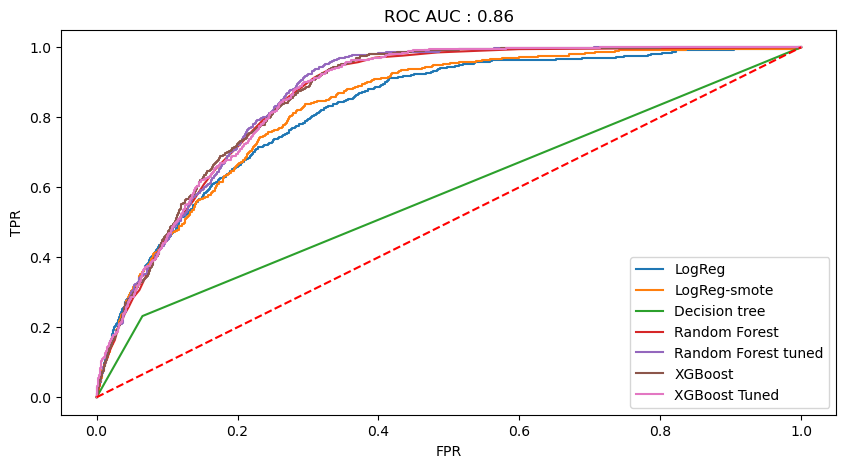

In [147]:
# plot the roc curve 
fpr_xgbtuned,tpr_xgbtuned,thres_xgbtuned = roc_curve(y_test,ypred_s_xgb_tuned)

plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_smote,tpr_lr_smote,label='LogReg-smote')
plt.plot(fpr_dt,tpr_dt,label='Decision tree')
plt.plot(fpr_rf,tpr_rf,label='Random Forest')
plt.plot(fpr_rftuned,tpr_rftuned,label='Random Forest tuned')
plt.plot(fpr_xgb,tpr_xgb,label = 'XGBoost')
plt.plot(fpr_xgbtuned,tpr_xgbtuned,label='XGBoost Tuned')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_xgb_tuned),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# Light Gradient Boosting Machine

In [150]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [151]:
from lightgbm import LGBMClassifier


In [152]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]


In [153]:
# Convert all column names to string
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

# Remove special characters
x_train.columns = x_train.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)
x_test.columns = x_test.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

In [154]:
lgb_model = LGBMClassifier(
    random_state=42,
    class_weight="balanced"   # OR use scale_pos_weight=ratio
)

lgb_model.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 2157, number of negative: 29587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002854 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 31744, number of used features: 195
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', random_state=42)

In [155]:
ypred_s_lgb = lgb_model.predict_proba(x_test)[:,1]
ypred_h_lgb = (ypred_s_lgb > 0.5).astype(int)


In [156]:
metrics(lgb_model,'Light GBM',x_train,y_train,x_test,y_test)

[LightGBM] [Info] Number of positive: 2157, number of negative: 29587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 31744, number of used features: 195
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Confusion Matrix:
 [[5474 1924]
 [  83  456]]

Classification Report for Light GBM:

              precision    recall  f1-score   support

           0       0.99      0.74      0.85      7398
           1       0.19      0.85      0.31       539

    accuracy                           0.75      7937
   macro avg       0.59      0.79      0.58      7937
weighted avg       0.93      0.75      0.81      7937

-------------------------------

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
0,Logistic Regression,0.93,0.40,0.05,0.09,0.82,0.08
1,Logistic Regression tuned,0.79,0.20,0.65,0.30,0.83,0.22
2,Decision Tree,0.89,0.21,0.23,0.22,0.58,0.16
3,Random Forest,0.93,0.43,0.01,0.02,0.86,0.02
4,Random Forest Tuned,0.73,0.19,0.89,0.31,0.86,0.22
5,XGBoost,0.93,0.39,0.07,0.12,0.86,0.10
6,XGBoost tuned,0.78,0.20,0.75,0.31,0.86,0.23
7,Light GBM,0.75,0.19,0.85,0.31,0.86,0.23


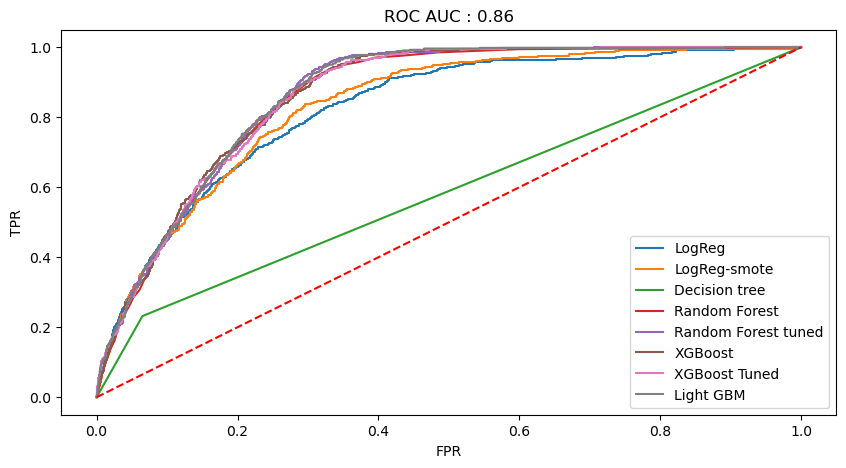

In [157]:
# plot the roc curve 
fpr_lgb,tpr_lgb,thres_lgb = roc_curve(y_test,ypred_s_lgb)

plt.plot(fpr_lr,tpr_lr,label='LogReg')
plt.plot(fpr_lr_smote,tpr_lr_smote,label='LogReg-smote')
plt.plot(fpr_dt,tpr_dt,label='Decision tree')
plt.plot(fpr_rf,tpr_rf,label='Random Forest')
plt.plot(fpr_rftuned,tpr_rftuned,label='Random Forest tuned')
plt.plot(fpr_xgb,tpr_xgb,label = 'XGBoost')
plt.plot(fpr_xgbtuned,tpr_xgbtuned,label='XGBoost Tuned')
plt.plot(fpr_lgb,tpr_lgb,label = 'Light GBM')
plt.plot([0,1],[0,1],ls='--',color = 'red')
plt.title(f'ROC AUC : {round(roc_auc_score(y_test,ypred_s_lgb),2)}')
plt.legend()
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.show()

# Inferences

1. LightGBM achieved high recall (0.85), effectively detecting most multi-fatal crashes
2. The model maintained a good balance between precision and recall, with F1-score of 0.31
3. False negatives are low (83), meaning very few multi-fatal crashes are missed
4. Accuracy (75%) is lower due to imbalance handling, but this is acceptable for the problem
5. ROC-AUC (~0.86) indicates strong ability to distinguish between single and multi-fatal crashes
6. The model produces more false positives, showing a trade-off for higher recall

In [159]:
summary.sort_values(by='Recall',ascending=False)

,Name,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Cohen_Kappa
4,Random Forest Tuned,0.73,0.19,0.89,0.31,0.86,0.22
7,Light GBM,0.75,0.19,0.85,0.31,0.86,0.23
6,XGBoost tuned,0.78,0.20,0.75,0.31,0.86,0.23
1,Logistic Regression tuned,0.79,0.20,0.65,0.30,0.83,0.22
2,Decision Tree,0.89,0.21,0.23,0.22,0.58,0.16
5,XGBoost,0.93,0.39,0.07,0.12,0.86,0.10
0,Logistic Regression,0.93,0.40,0.05,0.09,0.82,0.08
3,Random Forest,0.93,0.43,0.01,0.02,0.86,0.02


<Axes: xlabel='Name'>

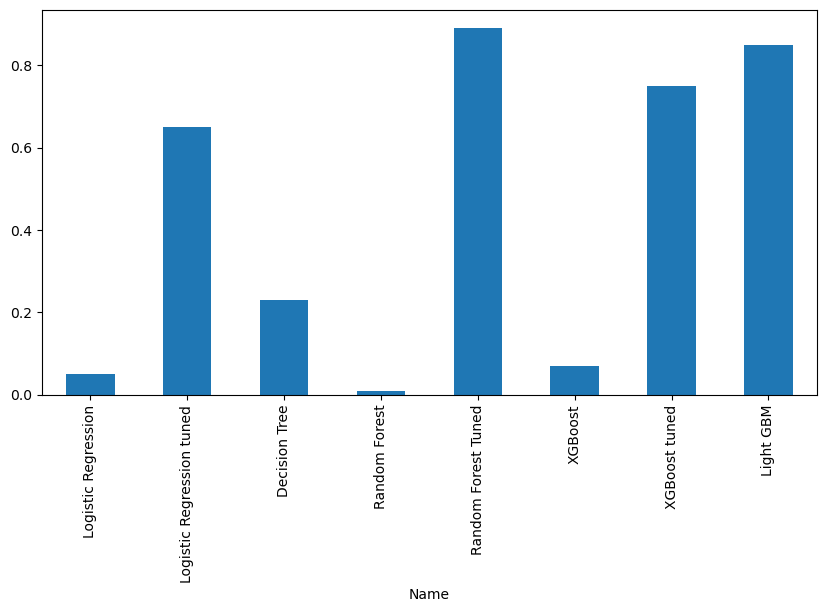

In [310]:
summary.set_index("Name")["Recall"].plot(kind="bar")

##  Model Inferences

- **Logistic Regression** showed **high accuracy** but failed to detect **multi-fatal crashes** (**very low recall**)

- After handling **class imbalance**, Logistic Regression improved **recall significantly** but reduced **overall accuracy**

- **Decision Tree** captured some patterns but performed poorly in detecting **multi-fatal crashes**

- **Random Forest (without tuning)** was **biased towards majority class** and failed to identify **minority cases**

- **Tuned Random Forest** achieved the **highest recall (0.89)**, making it the **best model for detecting multi-fatal crashes**

- **XGBoost** provided **balanced performance** but had **lower recall** compared to Random Forest

- **LightGBM** performed very close to Random Forest with **high recall (0.85)** and **strong overall metrics**

- **Ensemble models** (**Random Forest, XGBoost, LightGBM**) clearly **outperformed simpler models**

##  Final Insight

* The best model was selected based on recall (Class 1), as detecting multi-fatal crashes is more critical than overall accuracy

##  Top 5 Business Insights

- **Night-time and low visibility conditions** significantly increase the likelihood of **multi-fatal crashes**, indicating a need for improved lighting and visibility measures  

- **Multi-vehicle crashes** are more likely to result in **higher severity**, suggesting stricter traffic control and collision prevention systems  

- **Higher persons per vehicle** increases the risk of **multiple fatalities**, highlighting the importance of passenger safety regulations  

- **Rural night crashes** show elevated severity, indicating the need for better road infrastructure and emergency response in rural areas  

- Certain **collision types and harmful events** are strongly associated with **severe outcomes**, helping authorities identify and mitigate high-risk scenarios  